# 1.2. DataPrep: Cmax values
# 1.2. 数据准备：Cmax值

### 📘 Overview
### 📘 概述

This notebook compiles manually curated C<sub>max</sub> values from 20+ studies to assign a consensus median C<sub>max</sub> value for each compound.
这个notebook整合了来自20多个研究的手动整理的C<sub>max</sub>（最大血药浓度）值，为每个化合物分配一致的中位数C<sub>max</sub>值。

**Inputs**
**输入数据**
- Manually collected C<sub>max</sub> data from clinical and preclinical studies  
- 来自临床和临床前研究的手动收集的C<sub>max</sub>数据
- Compound names for alignment and deduplication
- 用于对齐和去重的化合物名称

**Output**  
**输出**  
A CSV file containing:  
一个包含以下内容的CSV文件：  
- Compound names  
- 化合物名称  
- All collected C<sub>max</sub> values  
- 所有收集的C<sub>max</sub>值  
- Median consensus C<sub>max</sub> per compound
- 每个化合物的一致中位数C<sub>max</sub>

In [1]:
%%capture

!pip install openpyxl

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import dilimap as dmap

In [3]:
dmap.logging.print_version()

Running dilimap 0.2.dev20+gc285bd842 (python 3.10.19) on 2025-11-20 01:14.


## Compile consensus median Cmax from various studies
## 从多个研究编译一致的中位数Cmax值

这一步从多个研究来源收集Cmax数据，计算每个化合物的中位数Cmax值。

In [ ]:
kwargs = {'header': 1, 'index_col': 0}
# 读取Excel文件的参数：第1行作为表头，第0列作为索引

df = dmap.s3.read('compound_Cmax_values.xlsx', sheet_name='CMAX (master)', **kwargs)
# 读取总Cmax数据（包含所有来源的Cmax值）
df_free = dmap.s3.read('compound_Cmax_values.xlsx', sheet_name='free CMAX', **kwargs)
# 读取游离Cmax数据（未与蛋白质结合的Cmax值）

Package: s3://dilimap/public/data. Top hash: 155a2b3b63
Package: s3://dilimap/public/data. Top hash: 155a2b3b63


In [5]:
df.loc[:, 'NCATS':'Manual'].head()

,NCATS,Porceddu12,Khetani13,Persson13,Aleo14,Garside14,Gustafsson14,Chen14,Shah15,Camenisch19,Dixit19,Aleo20,Williams20,Smit20,Manual
LIBRARY CMPDS,,,,,,,,,,,,,,,
Abacavir,NaN,NaN,NaN,NaN,NaN,NaN,NaN,14.90,14.8,14.90,14.31902,NaN,NaN,9.918279,19.068241
Acarbose,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.15,NaN,NaN,NaN,NaN,0.075897
Acebutolol,0.273463,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.27,1.39000,NaN,NaN,5.944773,2.737568
Aceclofenac,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39.43000,NaN,NaN,NaN,21.457410
Acetaminophen,NaN,130.0,NaN,NaN,NaN,165.387669,165.4,132.31,NaN,NaN,NaN,NaN,165.384393,117.094469,45.646997


In [ ]:
df['Cmax_median'] = df.loc[:, 'NCATS':'Manual'].median(axis=1, skipna=True)
# 计算总Cmax的中位数（跨多个研究来源）
df['Cmax_std'] = '+/- ' + df.loc[:, 'NCATS':'Manual'].std(axis=1, skipna=True).round(
    4
).astype(str)
# 计算总Cmax的标准差（用于表示数据的不确定性）

In [ ]:
df['free_Cmax_median'] = df_free['free_Cmax_median'] = df_free.loc[:, 'Garside14':'Dixit19'].median(axis=1, skipna=True)
# 计算游离Cmax的中位数（跨多个研究来源）
df['free_Cmax_std'] = df_free['free_Cmax_std'] = '+/- ' + df_free.loc[:, 'Garside14':'Dixit19'].std(
    axis=1, skipna=True
).round(4).astype(str)
# 计算游离Cmax的标准差

## Visualize
## 可视化

绘制总Cmax和游离Cmax的分布图，以及它们之间的相关性。

In [ ]:
# Drop NaNs and zeros
# 删除NaN和零值
df_filtered = df.dropna(subset=['Cmax_median', 'free_Cmax_median']).copy()
# 删除Cmax中位数缺失的行
df_filtered = df_filtered[
    (df_filtered['Cmax_median'] > 0) & (df_filtered['free_Cmax_median'] > 0)
]
# 只保留Cmax值大于0的化合物

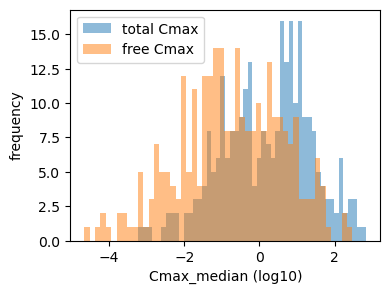

In [9]:
plt.subplots(figsize=(4, 3))
plt.hist(np.log10(df_filtered['Cmax_median']), alpha=0.5, bins=50, label='total Cmax')
plt.hist(np.log10(df_filtered['free_Cmax_median']), alpha=0.5, bins=50, label='free Cmax')
plt.xlabel('Cmax_median (log10)')
plt.ylabel('frequency')
plt.legend()

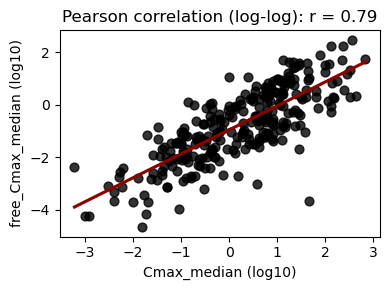

In [ ]:
from scipy.stats import pearsonr

# Compute Pearson correlation on log-transformed values
# 计算对数转换后的Pearson相关系数
log_x = np.log10(df_filtered['Cmax_median'])
# 总Cmax的对数值
log_y = np.log10(df_filtered['free_Cmax_median'])
# 游离Cmax的对数值
r, p_value = pearsonr(log_x, log_y)
# 计算相关系数和p值

# Plot
# 绘制散点图和回归线
plt.figure(figsize=(4, 3))
sns.regplot(
    x=log_x, y=log_y, ci=None, color='darkred', scatter_kws={'s': 40, 'color': 'k'}
)
# 绘制回归图（不显示置信区间）

plt.xlabel('Cmax_median (log10)')
# x轴标签：总Cmax中位数（对数）
plt.ylabel('free_Cmax_median (log10)')
# y轴标签：游离Cmax中位数（对数）
plt.title(f'Pearson correlation (log-log): r = {r:.2f}')
# 标题：显示Pearson相关系数
plt.tight_layout()
plt.show()

## Push file to S3
## 将文件推送到S3

保存处理后的Cmax数据到本地CSV文件，供后续使用。

In [11]:
df.to_csv('total_Cmax.csv')
df_free.to_csv('free_Cmax.csv')

In [12]:
# dmap.s3.write(df, 'compound_Cmax_values.csv')